In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from src.data_utils import load_california_housing

import sys
sys.path.append('..')

In [14]:
X, y = load_california_housing()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
alphas = np.logspace(-3, 1, 20)
results = []
coefficients = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    val_r2 = cv_scores.mean()
    train_r2 = model.score(X_train, y_train)
    n_nonzero = np.sum(np.abs(model.coef_) > 0)
    results.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'n_nonzero': n_nonzero
    })
    coefficients.append(model.coef_.copy())

results_df = pd.DataFrame(results)
coefficients = np.array(coefficients)
print(results_df.to_string(index=False))

    alpha  train_r2    val_r2  n_nonzero
 0.001000  0.612507  0.611496          8
 0.001624  0.612435  0.611456          8
 0.002637  0.612247  0.611314          7
 0.004281  0.611756  0.610885          7
 0.006952  0.610459  0.609657          7
 0.011288  0.607041  0.606284          7
 0.018330  0.598028  0.597198          7
 0.029764  0.582655  0.581621          6
 0.048329  0.550577  0.550286          4
 0.078476  0.506443  0.506113          3
 0.127427  0.485220  0.484972          2
 0.206914  0.445115  0.444889          1
 0.335982  0.392943  0.392714          1
 0.545559  0.255384  0.255108          1
 0.885867  0.000000 -0.000317          0
 1.438450  0.000000 -0.000317          0
 2.335721  0.000000 -0.000317          0
 3.792690  0.000000 -0.000317          0
 6.158482  0.000000 -0.000317          0
10.000000  0.000000 -0.000317          0


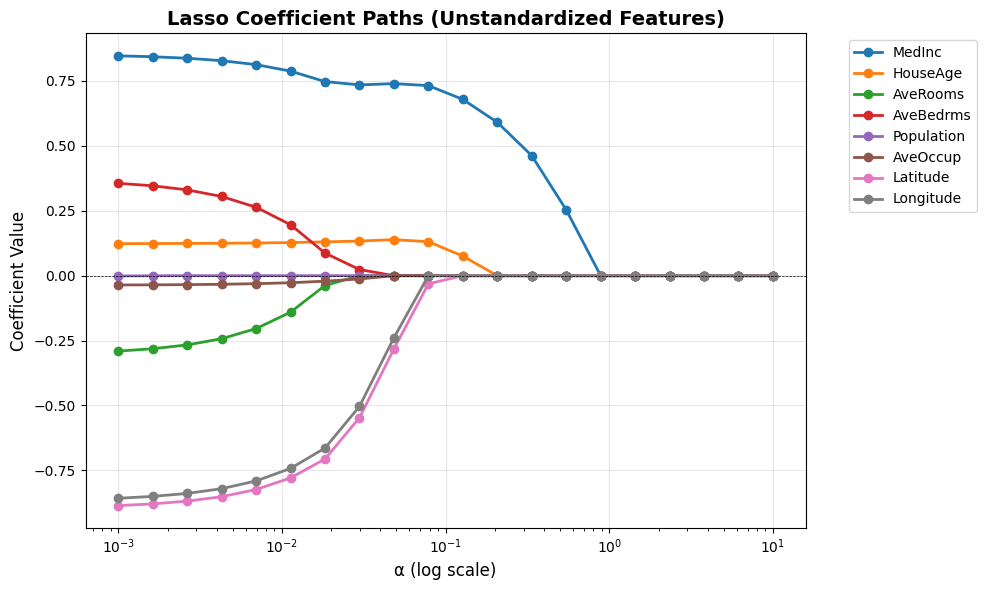

In [15]:
feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
                 'Population', 'AveOccup', 'Latitude', 'Longitude']
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(feature_names)):
    ax.plot(alphas, coefficients[:, i], 'o-', linewidth=2, label=feature_names[i])
ax.set_xscale('log')
ax.set_xlabel('α (log scale)', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Lasso Coefficient Paths (Unstandardized Features)', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

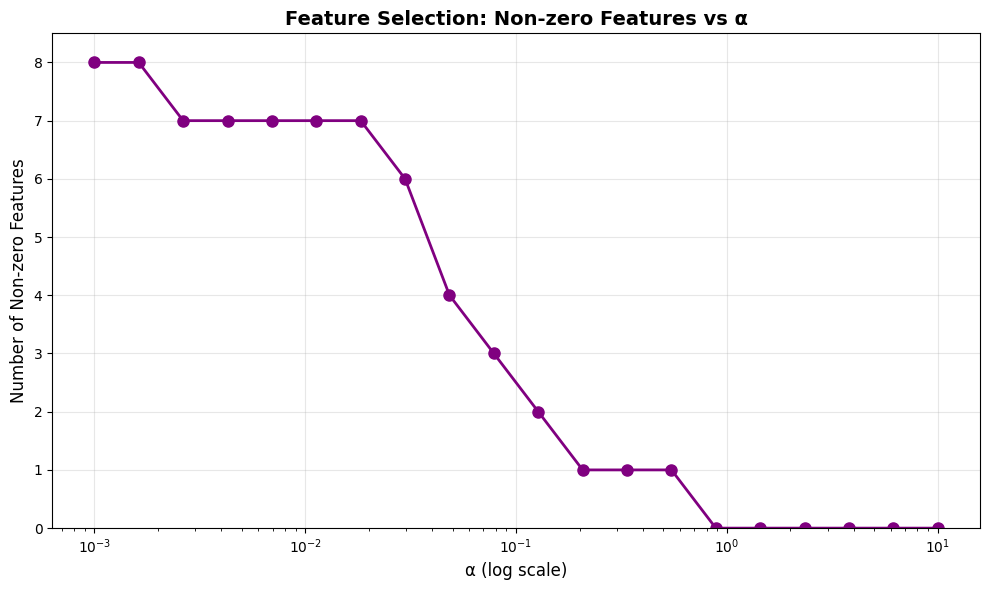

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(results_df['alpha'], results_df['n_nonzero'], 'o-', linewidth=2, markersize=8, color='purple')
ax.set_xlabel('α (log scale)', fontsize=12)
ax.set_ylabel('Number of Non-zero Features', fontsize=12)
ax.set_title('Feature Selection: Non-zero Features vs α', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, len(feature_names) + 0.5)
plt.tight_layout()
plt.show()

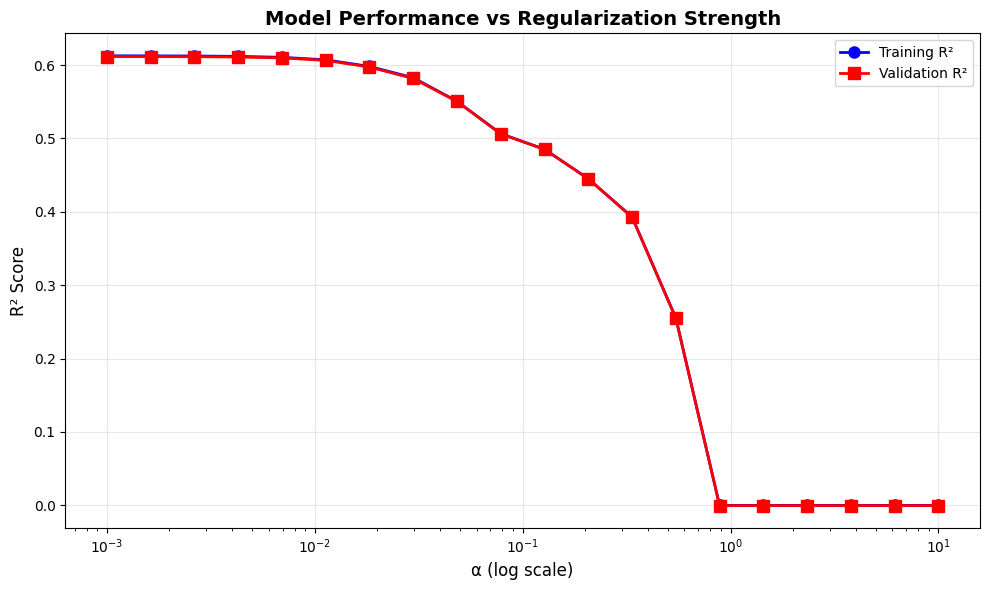

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(results_df['alpha'], results_df['train_r2'], 'o-', linewidth=2, 
            label='Training R²', color='blue', markersize=8)
ax.semilogx(results_df['alpha'], results_df['val_r2'], 's-', linewidth=2,
            label='Validation R²', color='red', markersize=8)
ax.set_xlabel('α (log scale)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Model Performance vs Regularization Strength', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
target_df = results_df[(results_df['n_nonzero'] >= 4) & (results_df['n_nonzero'] <= 6)]
if len(target_df) > 0:
    best_idx = target_df['val_r2'].idxmax()
    selected_alpha = results_df.loc[best_idx, 'alpha']
    selected_n = results_df.loc[best_idx, 'n_nonzero']
    
    print(f"Selected α = {selected_alpha:.4f} with {int(selected_n)} non-zero features")
    
    model_selected = Lasso(alpha=selected_alpha, max_iter=10000)
    model_selected.fit(X_train, y_train)
    selected_features = []
    for i, (name, coef) in enumerate(zip(feature_names, model_selected.coef_)):
        if np.abs(coef) > 1e-5:
            selected_features.append((name, coef))
            print(f"  {name:15s}: {coef:10.4f}")
    
    selected_indices = [i for i, coef in enumerate(model_selected.coef_) if np.abs(coef) > 1e-5]
    X_train_selected = X_train[:, selected_indices]
    X_test_selected = X_test[:, selected_indices]
    
    lr_selected = LinearRegression()
    lr_selected.fit(X_train_selected, y_train)
    r2_selected = lr_selected.score(X_test_selected, y_test)
    
    lr_all = LinearRegression()
    lr_all.fit(X_train, y_train)
    r2_all = lr_all.score(X_test, y_test)
    
    print(f"\nTest R² with selected features only: {r2_selected:.4f}")
    print(f"Test R² with all features: {r2_all:.4f}")
    print(f"Difference: {r2_selected - r2_all:.4f}")

Selected α = 0.0298 with 6 non-zero features
  MedInc         :     0.7347
  HouseAge       :     0.1333
  AveBedrms      :     0.0236
  AveOccup       :    -0.0127
  Latitude       :    -0.5471
  Longitude      :    -0.5035

Test R² with selected features only: 0.5799
Test R² with all features: 0.5758
Difference: 0.0042


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results_scaled = []
coefficients_scaled = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    val_r2 = cv_scores.mean()
    train_r2 = model.score(X_train_scaled, y_train)
    n_nonzero = np.sum(np.abs(model.coef_) > 1e-5)
    
    results_scaled.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'n_nonzero': n_nonzero
    })
    
    coefficients_scaled.append(model.coef_.copy())

results_scaled_df = pd.DataFrame(results_scaled)
coefficients_scaled = np.array(coefficients_scaled)

target_scaled_df = results_scaled_df[(results_scaled_df['n_nonzero'] >= 4) & 
                                      (results_scaled_df['n_nonzero'] <= 6)]
if len(target_scaled_df) > 0:
    best_idx_scaled = target_scaled_df['val_r2'].idxmax()
    selected_alpha_scaled = results_scaled_df.loc[best_idx_scaled, 'alpha']
    
    model_scaled = Lasso(alpha=selected_alpha_scaled, max_iter=10000)
    model_scaled.fit(X_train_scaled, y_train)
    
    print(f"\nSelected α (scaled) = {selected_alpha_scaled:.4f}")
    print("\nSelected features (standardized):")
    selected_features_scaled = []
    for i, (name, coef) in enumerate(zip(feature_names, model_scaled.coef_)):
        if np.abs(coef) > 1e-5:
            selected_features_scaled.append(name)
            print(f"  {name:15s}: {coef:10.4f}")

unstandardized_features = [f[0] for f in selected_features]
print(f"Unstandardized selected: {', '.join(unstandardized_features)}")
print(f"Standardized selected:   {', '.join(selected_features_scaled)}")



Selected α (scaled) = 0.0298

Selected features (standardized):
  MedInc         :     0.7364
  HouseAge       :     0.1335
  AveBedrms      :     0.0245
  AveOccup       :    -0.0111
  Latitude       :    -0.5490
  Longitude      :    -0.5057
Unstandardized selected: MedInc, HouseAge, AveBedrms, AveOccup, Latitude, Longitude
Standardized selected:   MedInc, HouseAge, AveBedrms, AveOccup, Latitude, Longitude


In [ ]:
most_persistent = []
for i, name in enumerate(feature_names):
    survival_count = np.sum(np.abs(coefficients_scaled[:, i]) > 1e-5)
    most_persistent.append((name, survival_count))

most_persistent.sort(key=lambda x: x[1], reverse=True)
for name, count in most_persistent[:4]:
    print(f"   - {name:15s}: survives {count}/{len(alphas)} α values")

   Features ranked by persistence (standardized):
   - MedInc         : survives 14/20 α values
   - HouseAge       : survives 11/20 α values
   - Latitude       : survives 10/20 α values
   - Longitude      : survives 9/20 α values


1. Features with weaker correlation to target drop out first and features with larger scale appear more important

2. Validation score slowly decreases at first then drastically drops down when most important features are removed

3. Without scaling the features with larger scales are treated as more important so it's important to scale the features first to perform selection on based on true importance

4. As we can see MedInc and HouseAge are most important for this dataset